# Notebook 02: Competición — Redes Densas (MLP)

En este notebook entrenamos **Multi-Layer Perceptrons (MLP)** sobre las
16 combinaciones de ventanas del taller.

## Estructura del notebook

1. Configuración e imports
2. Cargar datos y cargar resultados de baselines
3. Entender la arquitectura MLP (un modelo, una combinación)
4. Primer entrenamiento y diagnóstico de la curva
5. Comparar con los baselines del notebook 01
6. Probar variantes (pequeño, mediano, grande, con dropout)
7. Bucle completo: 16 combinaciones × 4 variantes
8. Resultados finales y reflexión

## Regla de oro
Si un MLP no bate consistentemente a la regresión lineal en test,
la complejidad añadida no está justificada.


## 1. Configuración e imports

In [1]:
import sys
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import random  


import tensorflow as tf

# Añadir raíz del proyecto al path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Raíz del proyecto: {project_root}")
print(f"¿Existe src/models.py? {(project_root / 'src' / 'models.py').exists()}")
print(f"¿Existen los datos?   {(project_root / 'data' / 'returns.parquet').exists()}")

Raíz del proyecto: c:\Users\alons\Desktop\B3_T4\taller-redes-neuronales
¿Existe src/models.py? True
¿Existen los datos?   True


In [27]:
from src.data       import cargar_returns, preparar_datos, TICKERS
from src.models     import (build_dense_model, contar_parametros)
from src.training   import entrenar_modelo, entrenar_todos_los_modelos, fijar_semilla
from src.evaluation import mae_global, construir_matriz_resultados
from src.plotting   import plot_curva_entrenamiento, plot_heatmap_mae

# Ventanas del taller 
INPUT_WINDOWS  = [5, 10, 30, 90]
OUTPUT_WINDOWS = [1, 5, 30, 90]

# Directorios de salida
FIGURES_DIR = project_root / "results" / "figures"
TABLES_DIR  = project_root / "results" / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Imports OK")

Imports OK


In [3]:
# ── Semilla global del notebook ──────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
print(f"Semilla fijada: {SEED}")

Semilla fijada: 42


## 2. Cargar datos y baselines de referencia

Cargamos los retornos y también los resultados del notebook 01.
Esos MAE de los baselines son el **suelo que debemos batir**.


In [4]:
returns = cargar_returns(verbose=True)
print(f"Rango: {returns.index.min().date()} → {returns.index.max().date()}")

[cargar_returns] Cargados 16192 días, 23 activos
Rango: 1962-01-03 → 2026-05-05


In [5]:
# Cargar baselines del notebook 01
baselines_path = TABLES_DIR / "01_baselines.csv"

if not baselines_path.exists():
    print("ATENCIÓN: no se encontró 01_baselines.csv")
    print("Ejecuta primero el notebook 01_baselines.ipynb")
else:
    df_baselines = pd.read_csv(baselines_path)
    
    # MAE en test del mejor baseline por combinación (nuestro suelo)
    suelo = (
        df_baselines
        .groupby(["V", "H"])["MAE_test"]
        .min()
        .reset_index()
        .rename(columns={"MAE_test": "MAE_suelo"})
    )
    print("Suelo a batir (mejor baseline en test) por combinación:")
    print(suelo.pivot(index="V", columns="H", values="MAE_suelo").round(5))

Suelo a batir (mejor baseline en test) por combinación:
H        1        5        30       90
V                                     
5   0.01226  0.00561  0.00234  0.00127
10  0.01226  0.00561  0.00235  0.00128
30  0.01227  0.00561  0.00236  0.00132
90  0.01229  0.00562  0.00236  0.00133


## 3. Entender la arquitectura MLP

Antes de entrenar nada, vamos a entender exactamente qué hace un MLP
y por qué tiene los parámetros que tiene.

Usamos V=30 y H=5 como ejemplo: el modelo mira 30 días de historia
de 23 activos y predice el promedio de los próximos 5 días.


In [6]:
# Preparamos los datos para V=30, H=5 (solo para ver la arquitectura)
datos = preparar_datos(returns, input_window=30, output_window=5, verbose=True)
input_shape = (30, 23)  # (V, num_activos)

print(f"\nForma de X_train: {datos['X_train'].shape}")
print(f"Forma de y_train: {datos['y_train'].shape}")

[preparar_datos] V=30, H=5
  X_train: (13815, 30, 23)   y_train: (13815, 23)
  X_val:   (727, 30, 23)   y_val:   (727, 23)
  X_test:  (1616, 30, 23)   y_test:  (1616, 23)

Forma de X_train: (13815, 30, 23)
Forma de y_train: (13815, 23)


In [7]:
# Creamos un MLP mediano y miramos su arquitectura
modelo_ejemplo = build_dense_model(
    input_shape=input_shape,
    hidden_units=[64, 32],   # 2 capas ocultas: 64 y 32 neuronas
    dropout=0.0,
)

modelo_ejemplo.summary()

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 690)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        44,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,063 (183.84 KB)

 Trainable params: 47,063 (183.84 KB)

 Non-trainable params: 0 (0.00 B)

### ¿Por qué tantos parámetros en la primera capa?

Fíjate en la capa `flatten`: convierte la entrada (30, 23) en un vector
de **30 × 23 = 690 features**.

La primera capa densa conecta esas 690 features con 64 neuronas:
```
690 × 64 (pesos) + 64 (bias) = 44.224 parámetros
```

Esto es lo que hace al MLP menos eficiente que las redes recurrentes
o convolucionales: **trata cada día y cada activo como una feature
independiente**, sin aprovechar el orden temporal ni las relaciones
entre activos.

Esto también significa que con V grande (90 días), el MLP tiene
muchos más parámetros y es más propenso a sobreajustar.


## 4. Primer entrenamiento

Entrenamos el modelo ejemplo (V=30, H=5) y observamos la curva.
Esto nos permitirá:
- Ver si el modelo aprende algo
- Detectar sobreajuste (train baja, val sube)
- Calibrar cuántas épocas necesitamos


In [8]:
# Reconstruimos el modelo (pesos frescos)
modelo_v30_h5 = build_dense_model(
    input_shape=(30, 23),
    hidden_units=[64, 32],
    dropout=0.0,
)

print(f"Parámetros: {contar_parametros(modelo_v30_h5):,}")

Parámetros: 47,063


In [9]:
history = entrenar_modelo(
    model=modelo_v30_h5,
    X_train=datos["X_train"],
    y_train=datos["y_train"],
    X_val=datos["X_val"],
    y_val=datos["y_val"],
    epochs=100,
    batch_size=32,
    patience=15,
    nombre="dense_mediano_V30_H5",
    verbose=0,   # 0=silencioso, cámbialo a 1 si quieres ver el progreso
)

epocas_entrenadas = len(history.history["loss"])
print(f"Épocas entrenadas: {epocas_entrenadas} (early stopping)")

Epoch 39: early stopping
Restoring model weights from the end of the best epoch: 24.
Épocas entrenadas: 39 (early stopping)


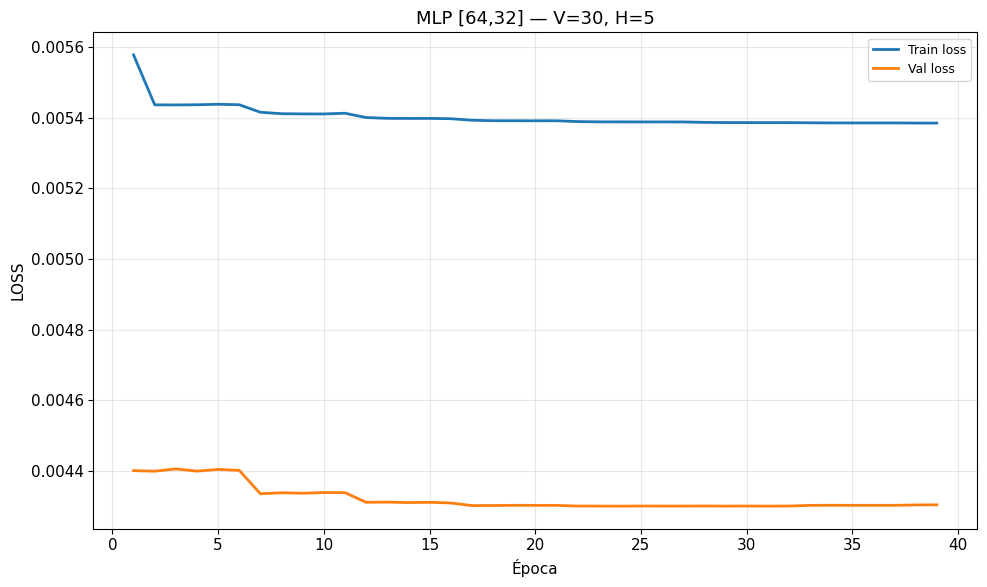

In [10]:
# Curva de entrenamiento
fig, ax = plot_curva_entrenamiento(
    history,
    title="MLP [64,32] — V=30, H=5",
)
plt.savefig(FIGURES_DIR / "02_curva_dense_mediano_V30_H5.png",
            bbox_inches="tight", dpi=120)
plt.show()

### ¿Cómo leer esta curva?

Mira las dos líneas (train y val) y responde:

**¿La curva de val baja junto con train?**
→ El modelo está aprendiendo correctamente.

**¿La curva de val empieza a subir mientras train sigue bajando?**
→ Sobreajuste. El modelo memoriza train pero no generaliza a val.

**¿Ambas curvas están planas desde el principio?**
→ El modelo no aprende nada. Posibles causas: learning rate muy bajo,
arquitectura demasiado pequeña, datos mal preparados.

**¿Hay saltos bruscos verticales?**
→ Inestabilidad en el entrenamiento. Prueba a bajar el learning rate.

Escribe aquí tu diagnóstico antes de seguir:
- ¿Convergió el modelo?
- ¿Hay sobreajuste?
- ¿En qué época para el early stopping?


## 5. Comparar con los baselines

Medimos el MAE del modelo en train, val y test, y lo comparamos
con el suelo del notebook 01.


In [11]:
mae_train = mae_global(datos["y_train"],
                       modelo_v30_h5.predict(datos["X_train"], verbose=0))
mae_val   = mae_global(datos["y_val"],
                       modelo_v30_h5.predict(datos["X_val"],   verbose=0))
mae_test  = mae_global(datos["y_test"],
                       modelo_v30_h5.predict(datos["X_test"],  verbose=0))

print(f"MAE train: {mae_train:.5f}")
print(f"MAE val:   {mae_val:.5f}")
print(f"MAE test:  {mae_test:.5f}")

MAE train: 0.00539
MAE val:   0.00430
MAE test:  0.00559


In [12]:
# Comparamos con el suelo del baseline para V=30, H=5
if 'suelo' in dir():
    mae_suelo = suelo[
        (suelo["V"] == 30) & (suelo["H"] == 5)
    ]["MAE_suelo"].values[0]

    print(f"\nComparación para V=30, H=5:")
    print(f"  Mejor baseline (suelo): {mae_suelo:.5f}")
    print(f"  MLP mediano:            {mae_test:.5f}")
    print()
    if mae_test < mae_suelo:
        mejora = (mae_suelo - mae_test) / mae_suelo * 100
        print(f"  ✓ El MLP BATE al baseline ({mejora:.1f}% de mejora)")
    else:
        diferencia = (mae_test - mae_suelo) / mae_suelo * 100
        print(f"  ✗ El MLP NO bate al baseline ({diferencia:.1f}% peor)")


Comparación para V=30, H=5:
  Mejor baseline (suelo): 0.00561
  MLP mediano:            0.00559

  ✓ El MLP BATE al baseline (0.4% de mejora)


### Reflexión

Si el MLP no bate al baseline, no te desesperes. Es un resultado
**muy común en forecasting financiero** y tiene sentido:

- Los retornos son casi ruido puro.
- El MLP tiene muchos parámetros (44k+) para muy poca señal.
- Al aplanar la entrada, pierde la estructura temporal.

En los notebooks 03 y 04 veremos si las redes recurrentes
y convolucionales lo hacen mejor.


## 6. Probar variantes de MLP

Ahora probamos 4 variantes para V=30, H=5, para entender cómo
afectan los hiperparámetros al resultado:

| Variante | Capas | Dropout | Parámetros aprox. |
|---|---|---|---|
| Pequeño | [32] | 0.0 | ~22k |
| Mediano | [64, 32] | 0.0 | ~47k |
| Grande | [128, 64, 32] | 0.0 | ~99k |
| Mediano + Dropout | [64, 32] | 0.2 | ~47k |

La regla de la tijera del profesor: empezamos pequeño y crecemos,
o empezamos grande y podamos. Aquí hacemos las dos para ver qué pasa.


In [13]:
# Definimos las 4 variantes
variantes = {
    "pequeño":          build_dense_model((30, 23), hidden_units=[32]),
    "mediano":          build_dense_model((30, 23), hidden_units=[64, 32]),
    "grande":           build_dense_model((30, 23), hidden_units=[128, 64, 32]),
    "mediano_dropout":  build_dense_model((30, 23), hidden_units=[64, 32],
                                          dropout=0.2),
}

for nombre, m in variantes.items():
    print(f"  {nombre:<20} {contar_parametros(m):>8,} parámetros")

  pequeño                22,871 parámetros
  mediano                47,063 parámetros
  grande                 99,543 parámetros
  mediano_dropout        47,063 parámetros


In [14]:
# Entrenamos las 4 variantes y guardamos resultados
print("Entrenando 4 variantes para V=30, H=5...")
print("(puede tardar 5-10 minutos en total)\n")

resultados_variantes = {}

for nombre, modelo in variantes.items():
    print(f"  → {nombre}...")
    hist = entrenar_modelo(
        model=modelo,
        X_train=datos["X_train"], y_train=datos["y_train"],
        X_val=datos["X_val"],     y_val=datos["y_val"],
        epochs=100, batch_size=32, patience=15,
        nombre=f"dense_{nombre}_V30_H5",
        verbose=0,
    )
    mae_te = mae_global(datos["y_test"],
                        modelo.predict(datos["X_test"], verbose=0))
    epocas = len(hist.history["loss"])
    resultados_variantes[nombre] = {
        "history": hist,
        "mae_test": mae_te,
        "n_params": contar_parametros(modelo),
        "epocas": epocas,
    }
    print(f"     MAE test={mae_te:.5f}  épocas={epocas}")

print("\nListo.")

Entrenando 4 variantes para V=30, H=5...
(puede tardar 5-10 minutos en total)

  → pequeño...
Epoch 46: early stopping
Restoring model weights from the end of the best epoch: 31.
     MAE test=0.00571  épocas=46
  → mediano...
Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 25.
     MAE test=0.00558  épocas=40
  → grande...
Epoch 35: early stopping
Restoring model weights from the end of the best epoch: 20.
     MAE test=0.00560  épocas=35
  → mediano_dropout...
Epoch 38: early stopping
Restoring model weights from the end of the best epoch: 23.
     MAE test=0.00559  épocas=38

Listo.


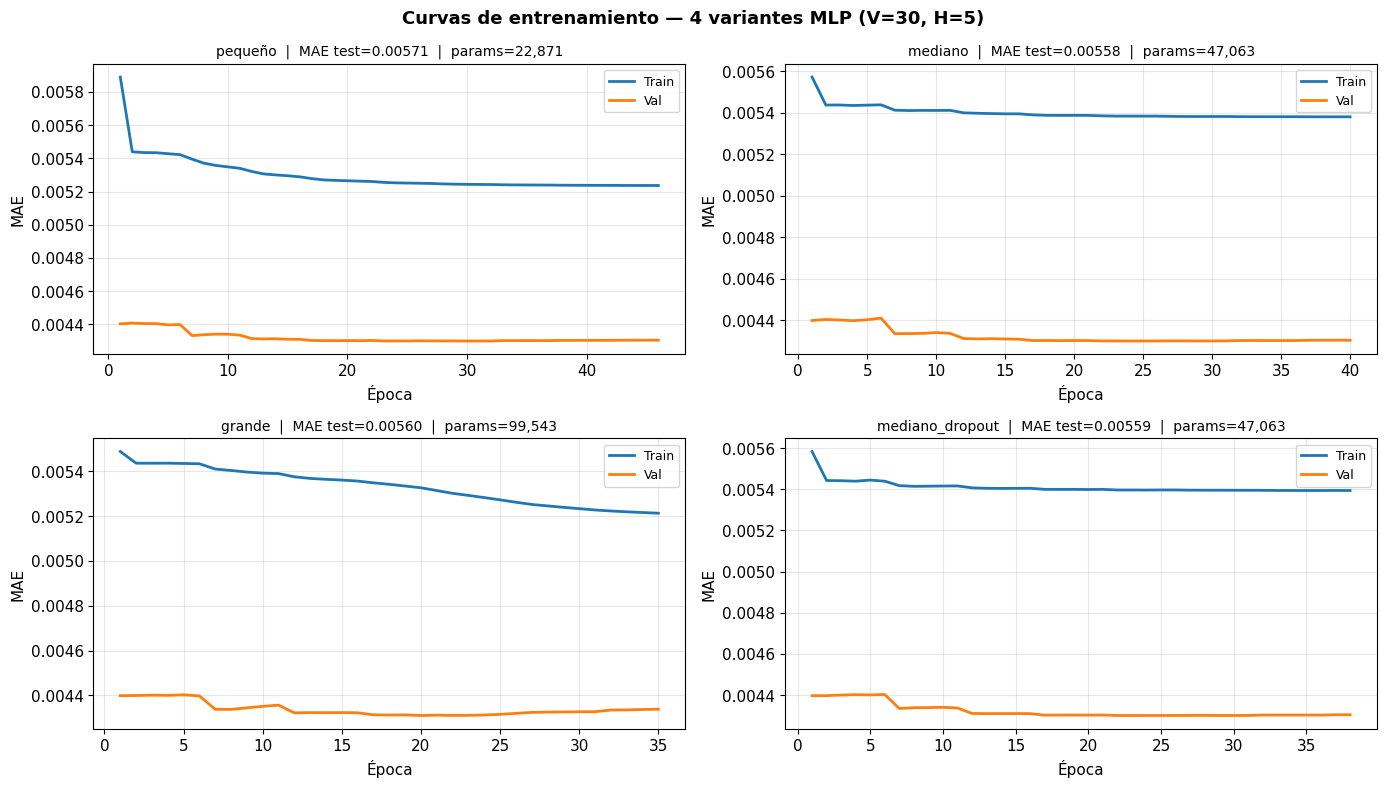

In [15]:
# Comparamos curvas de entrenamiento de las 4 variantes
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, (nombre, res) in enumerate(resultados_variantes.items()):
    ax = axes[idx]
    hist = res["history"].history
    epocas = range(1, len(hist["loss"]) + 1)
    ax.plot(epocas, hist["loss"],     label="Train", linewidth=2)
    ax.plot(epocas, hist["val_loss"], label="Val",   linewidth=2)
    ax.set_title(f"{nombre}  |  MAE test={res['mae_test']:.5f}  |  "
                 f"params={res['n_params']:,}", fontsize=10)
    ax.set_xlabel("Época")
    ax.set_ylabel("MAE")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Curvas de entrenamiento — 4 variantes MLP (V=30, H=5)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_curvas_variantes_V30_H5.png",
            bbox_inches="tight", dpi=120)
plt.show()

In [16]:
# Tabla comparativa de las 4 variantes + suelo baseline
print("Resumen variantes MLP para V=30, H=5:")
print("-" * 55)
print(f"{'Variante':<22} {'Params':>8}  {'MAE test':>10}  {'Épocas':>7}")
print("-" * 55)

for nombre, res in resultados_variantes.items():
    print(f"{nombre:<22} {res['n_params']:>8,}  {res['mae_test']:>10.5f}  "
          f"{res['epocas']:>7}")

if 'mae_suelo' in dir():
    print("-" * 55)
    print(f"{'Mejor baseline'::<22} {'---':>8}  {mae_suelo:>10.5f}  {'---':>7}")

print()
mejor = min(resultados_variantes, key=lambda k: resultados_variantes[k]["mae_test"])
print(f"Mejor variante: {mejor} "
      f"(MAE test = {resultados_variantes[mejor]['mae_test']:.5f})")

Resumen variantes MLP para V=30, H=5:
-------------------------------------------------------
Variante                 Params    MAE test   Épocas
-------------------------------------------------------
pequeño                  22,871     0.00571       46
mediano                  47,063     0.00558       40
grande                   99,543     0.00560       35
mediano_dropout          47,063     0.00559       38
-------------------------------------------------------
Mejor baseline::::::::      ---     0.00561      ---

Mejor variante: mediano (MAE test = 0.00558)


### ¿Qué deberías observar?

**¿Más capas = mejor resultado?**
No necesariamente. El modelo grande tiene más capacidad pero también
más tendencia a sobreajustar con datos financieros ruidosos.

**¿El dropout ayuda?**
Depende. Si el mediano sin dropout sobreajusta (val sube mientras train baja),
el mediano con dropout debería mostrar una val más estable.

**¿En qué época para cada modelo?**
El modelo pequeño probablemente para antes (convergencia más rápida).
El grande puede necesitar más épocas o no converger bien.

Escribe aquí tus observaciones:


## 7. Bucle completo: 16 combinaciones × 4 variantes

Ahora entrenamos todas las combinaciones. Esto tardará bastante
(estimación: 30-50 minutos en CPU).

**Consejo**: lanza el bucle, cierra el portátil y vuelve en un rato.
Los resultados se guardan automáticamente en disco, así que si algo
falla a mitad puedes recuperar lo que ya se entrenó.


In [17]:
# Definimos las variantes para el bucle completo
# La función builder recibe input_shape y devuelve un modelo compilado
BUILDERS_MLP = {
    "MLP_pequeño":         lambda s: build_dense_model(s, [32]),
    "MLP_mediano":         lambda s: build_dense_model(s, [64, 32]),
    "MLP_grande":          lambda s: build_dense_model(s, [128, 64, 32]),
    "MLP_mediano_dropout": lambda s: build_dense_model(s, [64, 32],
                                                        dropout=0.2),
}

print("Variantes a entrenar:")
for nombre in BUILDERS_MLP:
    print(f"  - {nombre}")
print(f"\nTotal entrenamientos: {len(BUILDERS_MLP)} × 16 = {len(BUILDERS_MLP)*16}")

Variantes a entrenar:
  - MLP_pequeño
  - MLP_mediano
  - MLP_grande
  - MLP_mediano_dropout

Total entrenamientos: 4 × 16 = 64


In [18]:
from src.training   import entrenar_todos_los_modelos

print("Iniciando entrenamiento completo...")
print("Esto puede tardar 30-50 minutos en CPU. Ten paciencia.\n")

resultados_mlp = entrenar_todos_los_modelos(
    builders=BUILDERS_MLP,
    returns=returns,
    input_windows=INPUT_WINDOWS,
    output_windows=OUTPUT_WINDOWS,
    epochs=100,
    batch_size=32,
    patience=15,
    verbose=0,
)

print(f"\n {len(resultados_mlp)} modelos entrenados.")

Iniciando entrenamiento completo...
Esto puede tardar 30-50 minutos en CPU. Ten paciencia.

[1/64] Entrenando MLP_pequeño_V5_H1...
Epoch 48: early stopping
Restoring model weights from the end of the best epoch: 33.
    MAE test=0.01245  params=4471  épocas=48
[2/64] Entrenando MLP_mediano_V5_H1...
Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 13.
    MAE test=0.01236  params=10263  épocas=28
[3/64] Entrenando MLP_grande_V5_H1...
Restoring model weights from the end of the best epoch: 99.
    MAE test=0.01234  params=25943  épocas=100
[4/64] Entrenando MLP_mediano_dropout_V5_H1...
Epoch 44: early stopping
Restoring model weights from the end of the best epoch: 29.
    MAE test=0.01227  params=10263  épocas=44
[5/64] Entrenando MLP_pequeño_V5_H5...
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 5.
    MAE test=0.00563  params=4471  épocas=20
[6/64] Entrenando MLP_mediano_V5_H5...
Epoch 32: early stopping
Restoring mode

In [19]:
# Guardar resultados en disco
df_mlp = pd.DataFrame(resultados_mlp).round(6)
df_mlp.to_csv(TABLES_DIR / "02_densas.csv", index=False)
print(f"Resultados guardados en results/tables/02_densas.csv")
print(f"\nPrimeras filas:")
df_mlp.head(8)

Resultados guardados en results/tables/02_densas.csv

Primeras filas:


,modelo,V,H,MAE_train,MAE_val,MAE_test,n_params,epocas_entrenadas
0,MLP_pequeño,5,1,0.011467,0.009209,0.012450,4471,48
1,MLP_mediano,5,1,0.011508,0.009216,0.012359,10263,28
2,MLP_grande,5,1,0.011407,0.009195,0.012336,25943,100
3,MLP_mediano_dropout,5,1,0.011573,0.009216,0.012268,10263,44
4,MLP_pequeño,5,5,0.005405,0.004299,0.005631,4471,20
5,MLP_mediano,5,5,0.005351,0.004299,0.005623,10263,32
6,MLP_grande,5,5,0.005413,0.004304,0.005615,25943,19
7,MLP_mediano_dropout,5,5,0.005413,0.004305,0.005595,10263,16


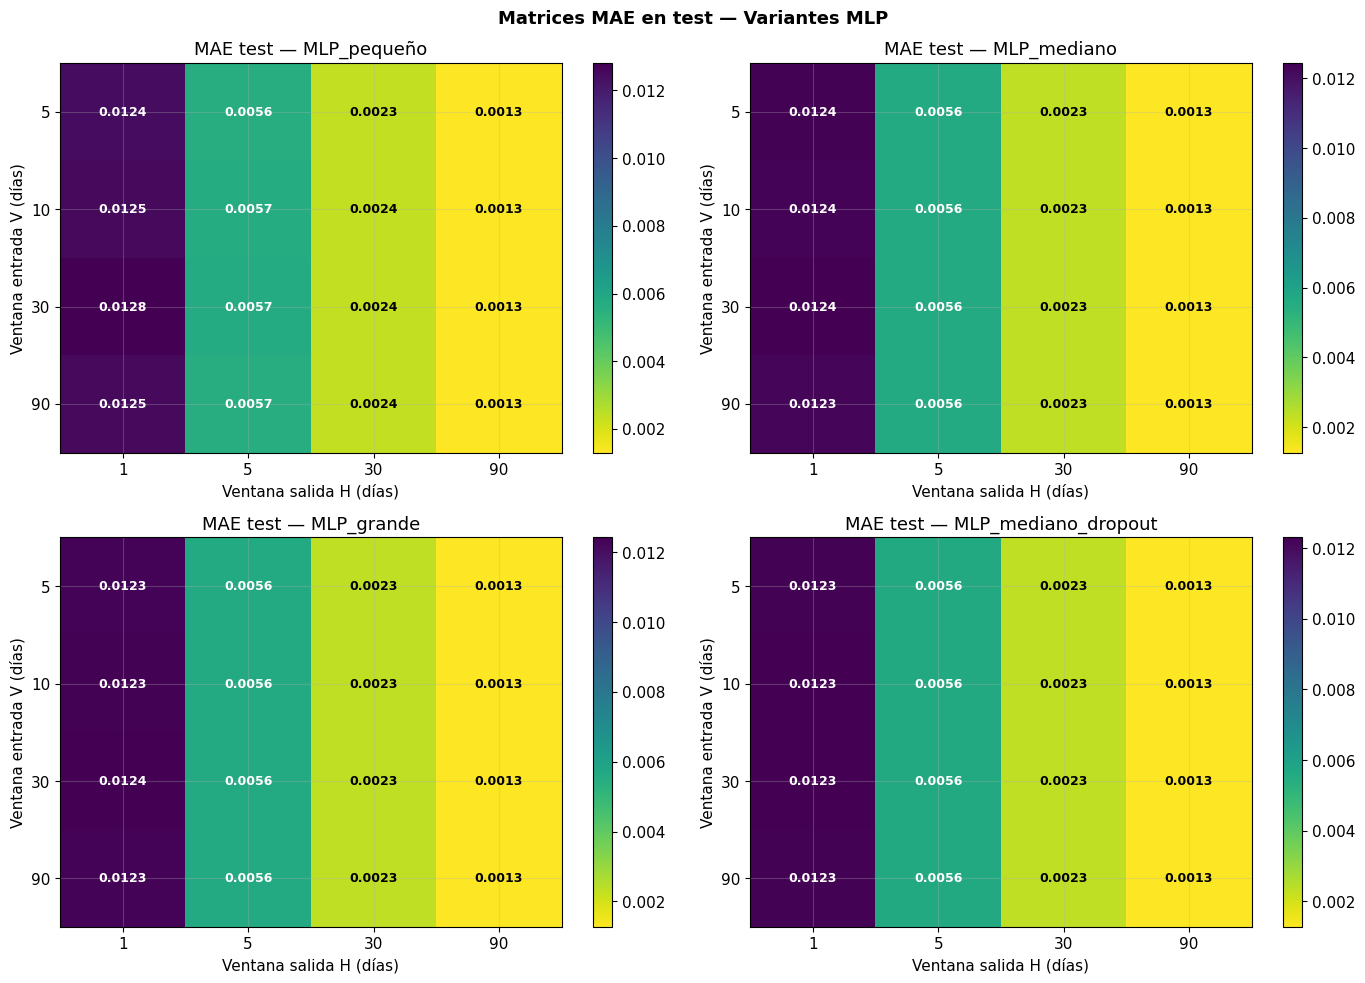

In [20]:
# Matrices 4×4 para cada variante MLP
variantes_nombres = list(BUILDERS_MLP.keys())
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, variante in enumerate(variantes_nombres):
    df_v = df_mlp[df_mlp["modelo"] == variante]
    matriz = construir_matriz_resultados(
        df_v.to_dict("records"), INPUT_WINDOWS, OUTPUT_WINDOWS
    )
    ax = axes[idx]
    im = ax.imshow(matriz, cmap="viridis_r", origin="upper", aspect="auto")
    for i in range(len(INPUT_WINDOWS)):
        for j in range(len(OUTPUT_WINDOWS)):
            val = matriz[i, j]
            if not np.isnan(val):
                color = "white" if val > np.nanmedian(matriz) else "black"
                ax.text(j, i, f"{val:.4f}", ha="center", va="center",
                        color=color, fontsize=9, fontweight="bold")
    ax.set_xticks(range(len(OUTPUT_WINDOWS)))
    ax.set_yticks(range(len(INPUT_WINDOWS)))
    ax.set_xticklabels(OUTPUT_WINDOWS)
    ax.set_yticklabels(INPUT_WINDOWS)
    ax.set_xlabel("Ventana salida H (días)")
    ax.set_ylabel("Ventana entrada V (días)")
    ax.set_title(f"MAE test — {variante}")
    plt.colorbar(im, ax=ax)

plt.suptitle("Matrices MAE en test — Variantes MLP", fontsize=13,
             fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_matrices_mlp.png", bbox_inches="tight", dpi=120)
plt.show()

In [21]:
# Mejor MLP por combinación
mejor_mlp = (
    df_mlp
    .loc[df_mlp.groupby(["V", "H"])["MAE_test"].idxmin()]
    [["V", "H", "modelo", "MAE_test", "MAE_train", "n_params", "epocas_entrenadas"]]
    .sort_values(["V", "H"])
    .reset_index(drop=True)
)

print("Mejor MLP por combinación:")
print(mejor_mlp.to_string(index=False))

Mejor MLP por combinación:
 V  H              modelo  MAE_test  MAE_train  n_params  epocas_entrenadas
 5  1 MLP_mediano_dropout  0.012268   0.011573     10263                 44
 5  5 MLP_mediano_dropout  0.005595   0.005413     10263                 16
 5 30          MLP_grande  0.002318   0.002171     25943                 67
 5 90 MLP_mediano_dropout  0.001262   0.001252     10263                 23
10  1 MLP_mediano_dropout  0.012282   0.011581     17623                 46
10  5 MLP_mediano_dropout  0.005588   0.005387     17623                 40
10 30          MLP_grande  0.002321   0.002173     40663                 43
10 90 MLP_mediano_dropout  0.001266   0.001253     17623                 28
30  1 MLP_mediano_dropout  0.012313   0.011552     47063                 37
30  5          MLP_grande  0.005587   0.005398     99543                 38
30 30         MLP_mediano  0.002319   0.002171     47063                 71
30 90          MLP_grande  0.001266   0.001241     99543     

In [22]:
# Comparación MLP vs Baselines por combinación
if 'suelo' in dir():
    comparacion = mejor_mlp.merge(suelo, on=["V", "H"])
    comparacion["mejora_%"] = (
        (comparacion["MAE_suelo"] - comparacion["MAE_test"])
        / comparacion["MAE_suelo"] * 100
    ).round(2)
    comparacion["bate_baseline"] = comparacion["MAE_test"] < comparacion["MAE_suelo"]

    print("Comparación mejor MLP vs mejor Baseline:")
    print(comparacion[["V", "H", "MAE_test", "MAE_suelo",
                         "mejora_%", "bate_baseline"]].to_string(index=False))
    print()
    n_bate = comparacion["bate_baseline"].sum()
    print(f"El MLP bate al baseline en {n_bate}/16 combinaciones.")

Comparación mejor MLP vs mejor Baseline:
 V  H  MAE_test  MAE_suelo  mejora_%  bate_baseline
 5  1  0.012268   0.012258     -0.08          False
 5  5  0.005595   0.005607      0.21           True
 5 30  0.002318   0.002337      0.81           True
 5 90  0.001262   0.001274      0.94           True
10  1  0.012282   0.012262     -0.16          False
10  5  0.005588   0.005607      0.34           True
10 30  0.002321   0.002354      1.40           True
10 90  0.001266   0.001284      1.40           True
30  1  0.012313   0.012269     -0.36          False
30  5  0.005587   0.005611      0.43           True
30 30  0.002319   0.002355      1.53           True
30 90  0.001266   0.001324      4.38           True
90  1  0.012267   0.012287      0.16           True
90  5  0.005597   0.005619      0.39           True
90 30  0.002332   0.002356      1.02           True
90 90  0.001270   0.001326      4.22           True

El MLP bate al baseline en 13/16 combinaciones.


## 8. Reflexión final

Antes de pasar al notebook 03 (redes recurrentes), reflexiona:

**¿En qué combinaciones gana el MLP pequeño vs el grande?**
¿Hay una relación entre el tamaño de V y qué variante es mejor?

**¿El dropout ayuda en algún caso?**
Fíjate si en las combinaciones donde el mediano sobreajusta,
el mediano con dropout tiene mejor MAE en test.

**¿En qué horizontes H el MLP bate al baseline?**
¿Es más fácil para el MLP predecir H=1 o H=90?

**¿El número de parámetros importa?**
Compara el MLP grande (más parámetros) con el pequeño.
¿Más parámetros siempre significa mejor resultado en test?

---

**Siguiente paso**: notebook 03 — Redes Recurrentes (LSTM y GRU).
Veremos si la estructura temporal que el MLP ignora (al aplanar la entrada)
aporta información real para este problema.


In [23]:
import keras
from src.models import build_dense_model
from src.evaluation import mae_global
from src.plotting import plot_curva_entrenamiento
import matplotlib.pyplot as plt

batch_sizes = [16, 32, 64, 128]
resultados_batch = {}

for bs in batch_sizes:
    print(f"Entrenando con batch_size={bs}...")
    
    modelo = build_dense_model(
        input_shape=(30, 23),
        hidden_units=[64, 32],
    )
    
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            min_delta=1e-5,
            restore_best_weights=True,
            verbose=0,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=0,
        ),
    ]
    
    hist = modelo.fit(
        datos["X_train"], datos["y_train"],
        validation_data=(datos["X_val"], datos["y_val"]),
        epochs=150,
        batch_size=bs,
        callbacks=callbacks,
        verbose=0,
    )
    
    epocas = len(hist.history["loss"])
    mae_te = mae_global(
        datos["y_test"],
        modelo.predict(datos["X_test"], verbose=0)
    )
    
    resultados_batch[bs] = {
        "history": hist,
        "mae_test": mae_te,
        "epocas": epocas,
    }
    print(f"  batch={bs:3d}  MAE test={mae_te:.5f}  épocas={epocas}")

Entrenando con batch_size=16...
  batch= 16  MAE test=0.00560  épocas=32
Entrenando con batch_size=32...
  batch= 32  MAE test=0.00559  épocas=37
Entrenando con batch_size=64...
  batch= 64  MAE test=0.00562  épocas=22
Entrenando con batch_size=128...
  batch=128  MAE test=0.00563  épocas=16


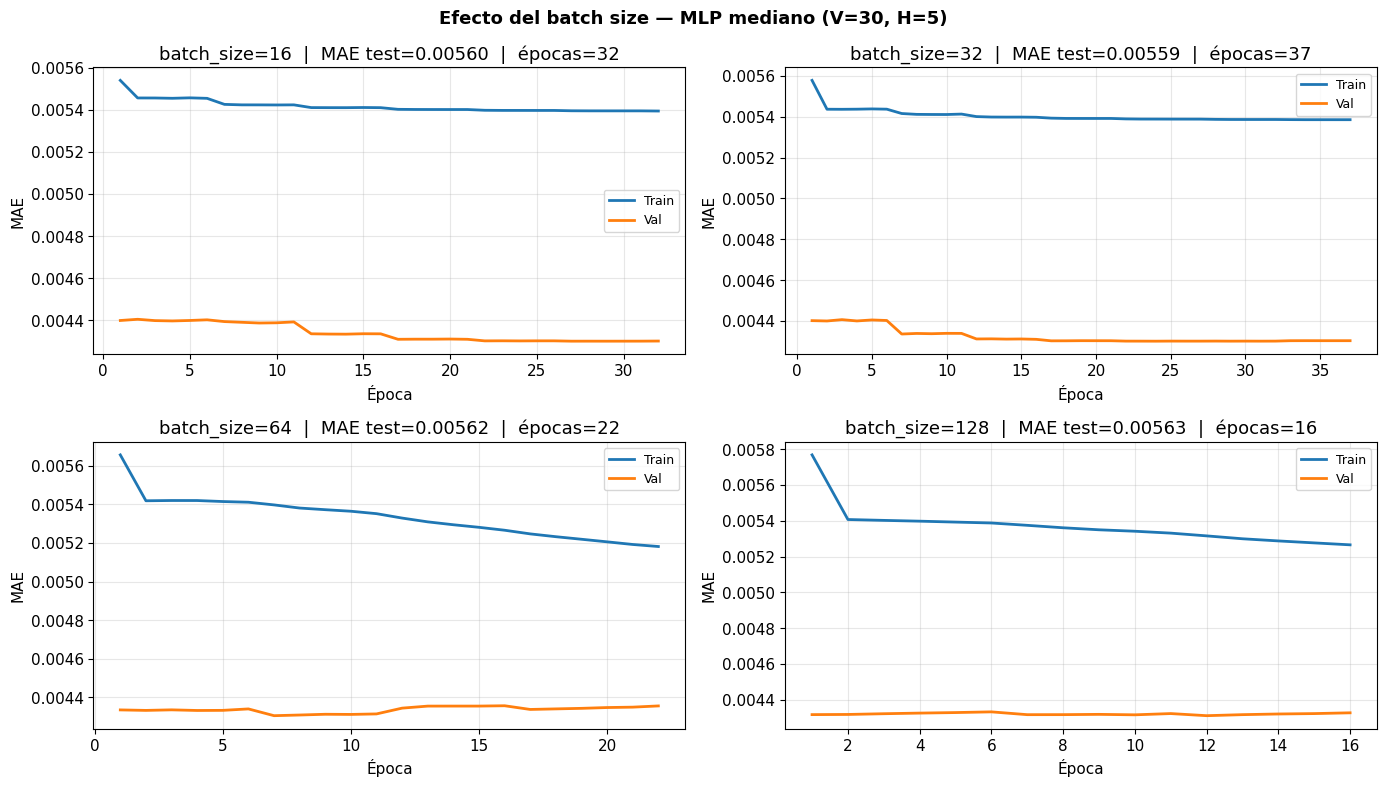

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, (bs, res) in enumerate(resultados_batch.items()):
    ax = axes[idx]
    hist = res["history"].history
    epocas = range(1, len(hist["loss"]) + 1)
    ax.plot(epocas, hist["loss"],     label="Train", linewidth=2)
    ax.plot(epocas, hist["val_loss"], label="Val",   linewidth=2)
    ax.set_title(f"batch_size={bs}  |  MAE test={res['mae_test']:.5f}"
                 f"  |  épocas={res['epocas']}")
    ax.set_xlabel("Época")
    ax.set_ylabel("MAE")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Efecto del batch size — MLP mediano (V=30, H=5)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [28]:
import keras
from src.models import build_dense_model
from src.evaluation import mae_global
import matplotlib.pyplot as plt

# ── Función helper para construir modelos con distintas regularizaciones ──
def build_dense_regularizado(input_shape, hidden_units, 
                              regularizacion=None, dropout=0.0):
    """
    Construye un MLP con distintos tipos de regularización.
    regularizacion: None, 'l1', 'l2', 'l1_l2'
    """
    from keras import layers, Input, Model
    import keras
    
    # Configurar el regularizador
    if regularizacion == 'l1':
        reg = keras.regularizers.L1(1e-4)
    elif regularizacion == 'l2':
        reg = keras.regularizers.L2(1e-4)
    elif regularizacion == 'l1_l2':
        reg = keras.regularizers.L1L2(l1=1e-4, l2=1e-4)
    else:
        reg = None
    
    inputs = Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    
    for i, units in enumerate(hidden_units):
        x = layers.Dense(units, activation='relu',
                         kernel_regularizer=reg)(x)
        if dropout > 0.0:
            x = layers.Dropout(dropout)(x)
    
    outputs = layers.Dense(input_shape[1])(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mean_absolute_error')
    return model

# ── Experimentos ──────────────────────────────────────────
experimentos = {
    "Sin regularización": {"regularizacion": None,    "dropout": 0.0},
    "Dropout 0.3":        {"regularizacion": None,    "dropout": 0.3},
    "L1 (Lasso)":         {"regularizacion": "l1",    "dropout": 0.0},
    "L2 (Ridge)":         {"regularizacion": "l2",    "dropout": 0.0},
    "L1+L2 (ElasticNet)": {"regularizacion": "l1_l2", "dropout": 0.0},
    "L2 + Dropout":       {"regularizacion": "l2",    "dropout": 0.3},
}

resultados_reg = {}

for nombre, config in experimentos.items():
    fijar_semilla(SEED)
    
    modelo = build_dense_regularizado(
        input_shape=(30, 23),
        hidden_units=[64, 32],
        regularizacion=config["regularizacion"],
        dropout=config["dropout"],
    )
    
    # Sin early stopping para ver el efecto puro de la regularización
    hist = modelo.fit(
        datos["X_train"], datos["y_train"],
        validation_data=(datos["X_val"], datos["y_val"]),
        epochs=200,
        batch_size=32,
        verbose=0,
    )
    
    mae_te = mae_global(
        datos["y_test"],
        modelo.predict(datos["X_test"], verbose=0)
    )
    
    resultados_reg[nombre] = {
        "history": hist,
        "mae_test": mae_te,
    }
    print(f"{nombre:<25}  MAE test={mae_te:.5f}")

Sin regularización         MAE test=0.00613
Dropout 0.3                MAE test=0.00565
L1 (Lasso)                 MAE test=0.00565
L2 (Ridge)                 MAE test=0.00565
L1+L2 (ElasticNet)         MAE test=0.00565
L2 + Dropout               MAE test=0.00565


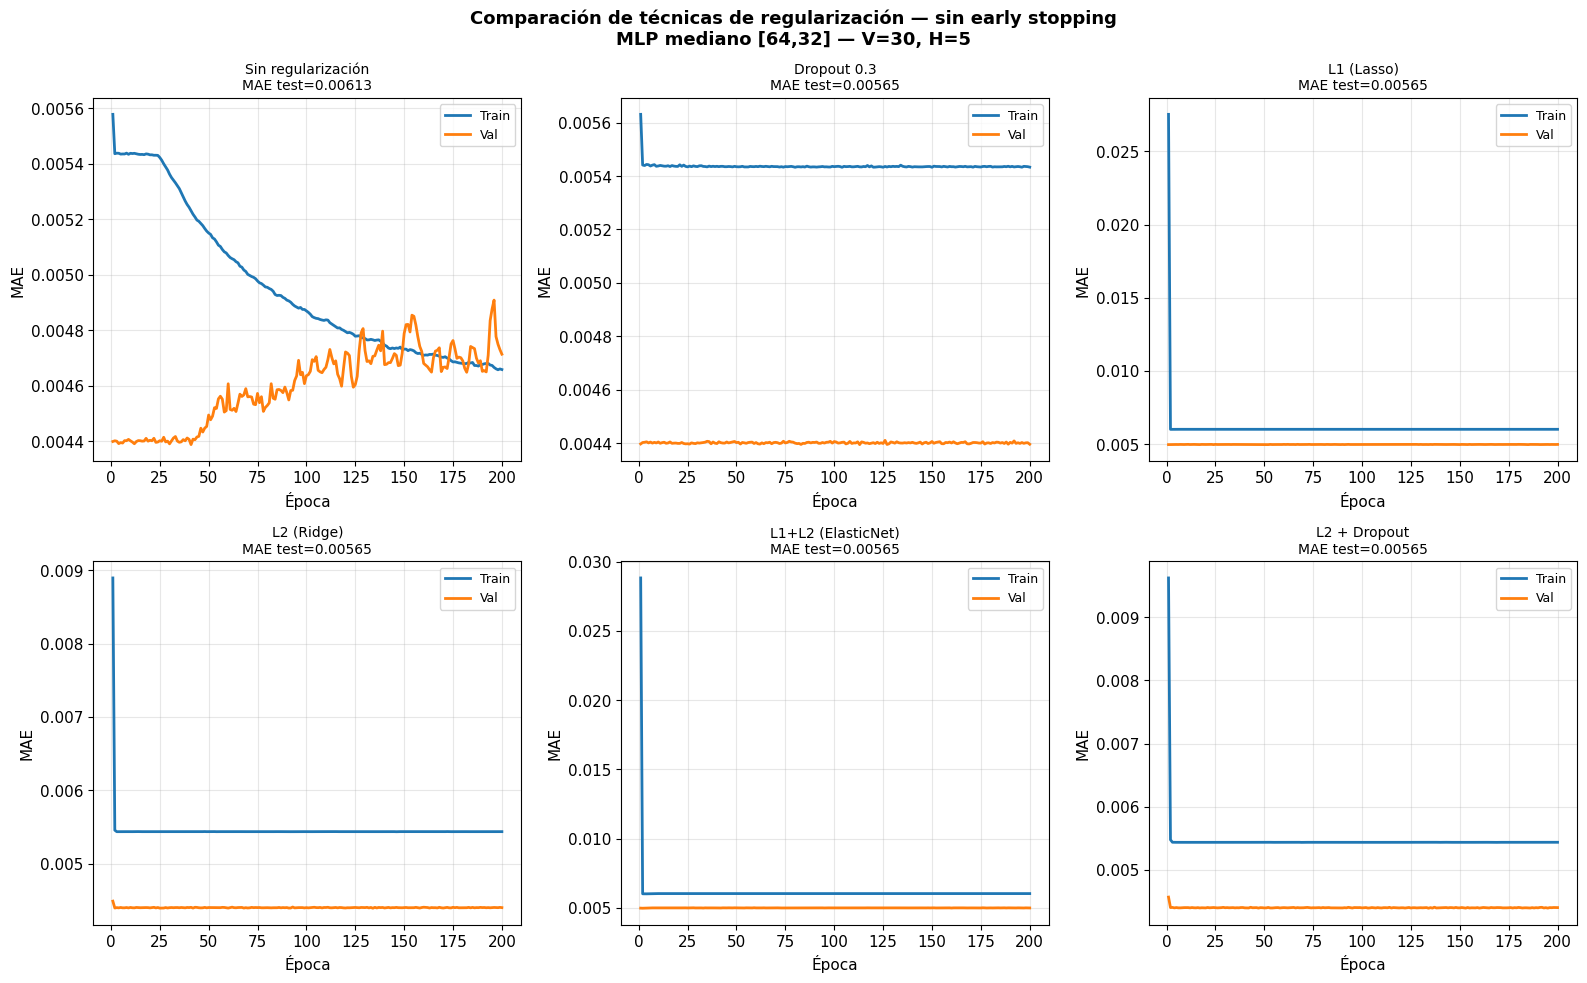


Resumen:
---------------------------------------------
Técnica                      MAE test
---------------------------------------------
Sin regularización            0.00613
Dropout 0.3                   0.00565
L1 (Lasso)                    0.00565
L2 (Ridge)                    0.00565
L1+L2 (ElasticNet)            0.00565
L2 + Dropout                  0.00565
---------------------------------------------
Early stopping (ref))         0.00561


In [29]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (nombre, res) in enumerate(resultados_reg.items()):
    ax = axes[idx]
    hist = res["history"].history
    epocas = range(1, len(hist["loss"]) + 1)
    ax.plot(epocas, hist["loss"],     label="Train", linewidth=2)
    ax.plot(epocas, hist["val_loss"], label="Val",   linewidth=2)
    ax.set_title(f"{nombre}\nMAE test={res['mae_test']:.5f}", fontsize=10)
    ax.set_xlabel("Época")
    ax.set_ylabel("MAE")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Comparación de técnicas de regularización — sin early stopping\n"
             "MLP mediano [64,32] — V=30, H=5",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Tabla resumen
print("\nResumen:")
print("-" * 45)
print(f"{'Técnica':<25}  {'MAE test':>10}")
print("-" * 45)
for nombre, res in resultados_reg.items():
    print(f"{nombre:<25}  {res['mae_test']:>10.5f}")
print("-" * 45)
print(f"{'Early stopping (ref))':<25}  {'0.00561':>10}")

lr=0.001  MAE test=0.00565
lr=0.0001  MAE test=0.00559
lr=1e-05  MAE test=0.00559
lr=1e-06  MAE test=0.00559
lr=1e-07  MAE test=0.00726


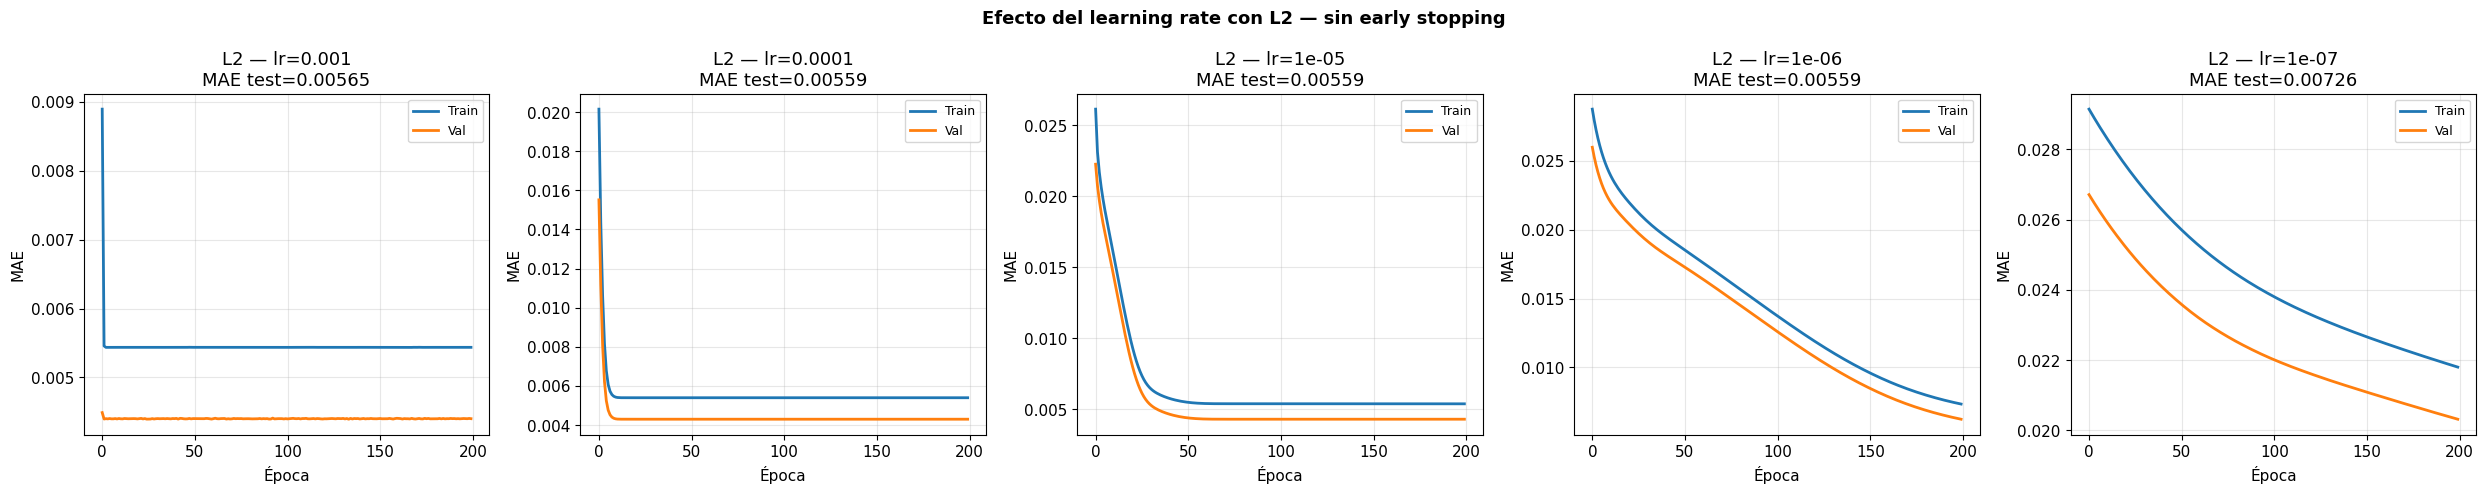

In [31]:
lrs = [1e-3, 1e-4, 1e-5,1e-6, 1e-7]
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for idx, lr in enumerate(lrs):
    fijar_semilla(SEED)
    
    modelo = build_dense_regularizado(
        input_shape=(30, 23),
        hidden_units=[64, 32],
        regularizacion='l2',
        dropout=0.0,
    )
    
    # Recompilar con el lr que queremos probar
    import keras
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mean_absolute_error'
    )
    
    hist = modelo.fit(
        datos["X_train"], datos["y_train"],
        validation_data=(datos["X_val"], datos["y_val"]),
        epochs=200,
        batch_size=32,
        verbose=0,
    )
    
    mae_te = mae_global(
        datos["y_test"],
        modelo.predict(datos["X_test"], verbose=0)
    )
    
    ax = axes[idx]
    ax.plot(hist.history["loss"],     label="Train", linewidth=2)
    ax.plot(hist.history["val_loss"], label="Val",   linewidth=2)
    ax.set_title(f"L2 — lr={lr}\nMAE test={mae_te:.5f}")
    ax.set_xlabel("Época")
    ax.set_ylabel("MAE")
    ax.legend()
    ax.grid(True, alpha=0.3)
    print(f"lr={lr}  MAE test={mae_te:.5f}")

plt.suptitle("Efecto del learning rate con L2 — sin early stopping",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Época  10  val=0.00440  test=0.00565
Época  20  val=0.00440  test=0.00565
Época  30  val=0.00439  test=0.00565
Época  40  val=0.00441  test=0.00573
Época  50  val=0.00449  test=0.00581
Época  60  val=0.00461  test=0.00589
Época  70  val=0.00456  test=0.00588
Época  80  val=0.00453  test=0.00585
Época  90  val=0.00458  test=0.00589
Época 100  val=0.00464  test=0.00589


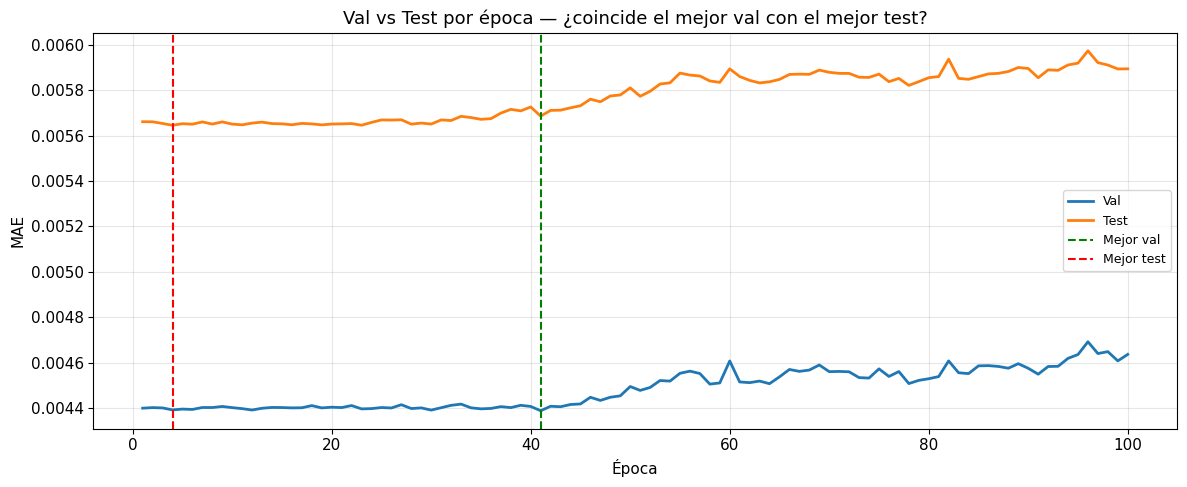


Mejor val en época:  41
Mejor test en época: 4
MAE test en mejor val:  0.00569
MAE test en mejor test: 0.00565


In [32]:
# Entrenamos epoch a epoch y guardamos MAE test en cada época
fijar_semilla(SEED)

modelo_check = build_dense_model(
    input_shape=(30, 23),
    hidden_units=[64, 32],
    dropout=0.0,
)

maes_test_por_epoca = []
maes_val_por_epoca = []

# Entrenamos de 1 en 1 para capturar el MAE test en cada época
for epoca in range(1, 101):
    modelo_check.fit(
        datos["X_train"], datos["y_train"],
        initial_epoch=epoca-1,
        epochs=epoca,
        batch_size=32,
        verbose=0,
    )
    mae_te = mae_global(
        datos["y_test"],
        modelo_check.predict(datos["X_test"], verbose=0)
    )
    mae_va = mae_global(
        datos["y_val"],
        modelo_check.predict(datos["X_val"], verbose=0)
    )
    maes_test_por_epoca.append(mae_te)
    maes_val_por_epoca.append(mae_va)
    
    if epoca % 10 == 0:
        print(f"Época {epoca:3d}  val={mae_va:.5f}  test={mae_te:.5f}")

# Plot val vs test época a época
fig, ax = plt.subplots(figsize=(12, 5))
epocas = range(1, 101)
ax.plot(epocas, maes_val_por_epoca,  label="Val",  linewidth=2)
ax.plot(epocas, maes_test_por_epoca, label="Test", linewidth=2)
ax.axvline(x=maes_val_por_epoca.index(min(maes_val_por_epoca))+1,
           color='green', linestyle='--', label="Mejor val")
ax.axvline(x=maes_test_por_epoca.index(min(maes_test_por_epoca))+1,
           color='red', linestyle='--', label="Mejor test")
ax.set_xlabel("Época")
ax.set_ylabel("MAE")
ax.set_title("Val vs Test por época — ¿coincide el mejor val con el mejor test?")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMejor val en época:  {maes_val_por_epoca.index(min(maes_val_por_epoca))+1}")
print(f"Mejor test en época: {maes_test_por_epoca.index(min(maes_test_por_epoca))+1}")
print(f"MAE test en mejor val:  {maes_test_por_epoca[maes_val_por_epoca.index(min(maes_val_por_epoca))]:.5f}")
print(f"MAE test en mejor test: {min(maes_test_por_epoca):.5f}")